# Whakaari Cause–Trigger Analysis

This notebook applies the Cause–Trigger analysis to the Whakaari case. **HMML is the baseline causal-discovery method**; PCMCI and PCMCI+ are extensions. PCMCI+ additionally evaluates eligible directed same-hour links (tau=0) as trigger candidates while retaining lagged variables for the causal component used to construct \(V\).

The main analysis uses maximum lag orders \(d=1,...,12\) for every backend. Minimum-\(I_2\) values 24, 36, and 48 h assess partition stability.

Minimum-\(I_2\) settings that generate the same split are **not treated as independent replications**. The backend × lag grid is executed once per unique partition, while all supporting minimum-\(I_2\) values remain recorded in the audit output.

The target effect is positive tremor-response anomaly. Moderation decisions use \(alpha=0.05\); case-wide Benjamini–Hochberg values are saved as a secondary multiplicity audit and do not replace the original F-test decision rule.

## Configuration

In [1]:
from pathlib import Path
import sys

import pandas as pd

pd.set_option("display.max_colwidth", 110)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 170)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cause_trigger_reporting import (
    automatic_lag_outcome_table,
    backend_split_summary,
    delayed_lag_correlation,
    export_audit_csvs,
    multiplicity_audit_summary,
    pair_split_lag_summary,
    plot_effect_with_splits,
    run_unique_split_grid,
    show_table,
    split_display_table,
    top_delayed_lags,
    warning_summary,
)
from cause_trigger_workflow import (
    COMPACT_RUN_SPECS,
    prepare_case_analysis,
    run_one,
)

from cause_trigger_cases import WHAKAARI_CASE

CASE = WHAKAARI_CASE
EFFECT = CASE.effect
VARIABLE_LABELS = CASE.variable_labels

DATA_PATH = PROJECT_ROOT / "data/whakaari/whakaari_dataset.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

SAVE_RESULTS = True
SHOW_FULL_GRID = False
SHOW_SCALING_REPORT = False

EVENT_TIME = pd.Timestamp("2019-12-09 01:11:00", tz="UTC")
EVENT_LABEL = "Whakaari eruption time"

CASE_PRE_DAYS = 3
CASE_POST_DAYS = 3
REFERENCE_DAYS = 14
REFERENCE_MIN_COVERAGE = 0.90

MIN_I1_LENGTH = 48
MIN_I2_GRID = (24, 36, 48)
LAG_GRID = tuple(range(1, 13))

ALPHA = 0.05
PCMCI_PC_ALPHA = 0.05
PCMCI_ALPHA_LEVEL = 0.05
PCMCI_FDR_METHOD = "fdr_bh"
COND_IND_TEST = "robust_parcorr"

## Data preparation and partition stability

The causal interval contains **4 days before** and **4 days after** the contextual event hour. The preceding 14-day reference interval is used only for transformation parameters and reference-standardised mean comparisons; it is not included in \(I_1\) or \(I_2\).

Item,Value
Dataset coverage,2019-10-01 12:00:00+00:00 to 2019-12-16 23:00:00+00:00 (1826 retained hourly rows)
Causal-analysis interval,"[2019-12-06 01:00:00+00:00, 2019-12-12 01:00:00+00:00) (144 h; 3 d before and 3 d after the event hour)"
Reference-standardisation interval,"[2019-11-22 01:00:00+00:00, 2019-12-06 01:00:00+00:00); 336/336 h (100.0% coverage)"
Whakaari eruption time,2019-12-09 01:11:00+00:00
Effect maximum,2019-12-09 01:00:00+00:00 (-1 days +23:49:00 from event)
Minimum interval design,"I1 >= 48 h; minimum-I2 grid = (24, 36, 48) h"
Maximum-lag-order design,"d = 1-12 h for HMML, PCMCI, and PCMCI+"
Unique split partitions,3 unique causal partition(s) from 3 causal minimum-I2 settings;
Causal run count,108 unique runs after split deduplication (108 rows would be produced without deduplication)


Minimum I2 (h),Causal grid,Partition,Split time,I1 (h),I2 (h),Split score,Boundary split,Offset from event
24,True,S3,2019-12-10 19:00:00+00:00,114,30,4.497588,False,1 days 17:49:00
36,True,S2,2019-12-10 13:00:00+00:00,108,36,3.903026,True,1 days 11:49:00
48,True,S1,2019-12-10 01:00:00+00:00,96,48,3.397977,True,0 days 23:49:00


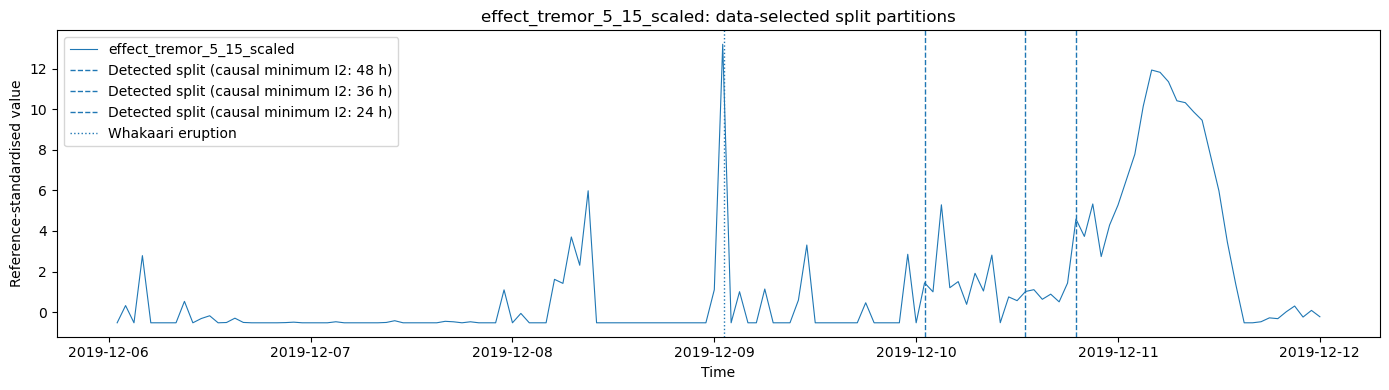

(<Figure size 1400x400 with 1 Axes>,
 <Axes: title={'center': 'effect_tremor_5_15_scaled: data-selected split partitions'}, xlabel='Time', ylabel='Reference-standardised value'>,
 [WindowsPath('c:/Users/cescedes/Desktop/Distinguishing Causes and Triggers in Volcanic and Seismic Processes/figures/whakaari_effect_splits.pdf'),
  WindowsPath('c:/Users/cescedes/Desktop/Distinguishing Causes and Triggers in Volcanic and Seismic Processes/figures/whakaari_effect_splits.png')])

In [2]:
analysis = prepare_case_analysis(
    data_path=DATA_PATH,
    case=CASE,
    event_time=EVENT_TIME,
    event_label=EVENT_LABEL,
    case_pre_days=CASE_PRE_DAYS,
    case_post_days=CASE_POST_DAYS,
    reference_days=REFERENCE_DAYS,
    reference_min_coverage=REFERENCE_MIN_COVERAGE,
    min_I1_length=MIN_I1_LENGTH,
    min_I2_values=MIN_I2_GRID,
    lag_grid=LAG_GRID,
    alpha=ALPHA,
    pcmci_pc_alpha=PCMCI_PC_ALPHA,
    pcmci_alpha_level=PCMCI_ALPHA_LEVEL,
    pcmci_fdr_method=PCMCI_FDR_METHOD,
    cond_ind_test=COND_IND_TEST,
)

show_table(analysis.design_summary, "Prespecified design and timing")
show_table(
    split_display_table(analysis.split_summary),
    "Effect split across causal and split-only minimum-I2 settings",
)

if SHOW_SCALING_REPORT:
    show_table(
        analysis.scaling_report.reset_index(names="Variable"),
        "Transformation and scaling audit",
    )

plot_effect_with_splits(
    analysis.X_mean,
    EFFECT,
    analysis.split_summary,
    event_time=EVENT_TIME,
    event_label="Whakaari eruption",
    filename="whakaari_effect_splits",
    save_dir=FIGURES_DIR,
)

## Cause–Trigger analysis over unique partitions

A maximum order \(d=k\) permits lagged relations from 1 through \(k\) hours. The grid is interpreted through recurrence across adjacent orders, unique partitions, and backends—not by selecting the smallest p-value.

In [3]:
experiment_grid, all_diagnostics = run_unique_split_grid(
    analysis.X_model,
    analysis.X_mean,
    analysis.workflow_template,
    analysis.split_summary,
    run_one=run_one,
    run_specs=COMPACT_RUN_SPECS,
    lags=LAG_GRID,
    cond_ind_test=COND_IND_TEST,
    metadata={
        "case_pre_days": CASE_PRE_DAYS,
        "case_post_days": CASE_POST_DAYS,
        "reference_days": REFERENCE_DAYS,
    },
)

expected_rows = (
    len(analysis.unique_splits)
    * len(LAG_GRID)
    * len(COMPACT_RUN_SPECS)
)
if len(experiment_grid) != expected_rows:
    raise RuntimeError(
        f"Incomplete unique-partition grid: expected {expected_rows} rows, "
        f"received {len(experiment_grid)}."
    )

backend_summary = backend_split_summary(
    experiment_grid,
    lag_count=len(LAG_GRID),
)
pair_summary = pair_split_lag_summary(
    all_diagnostics,
    experiment_grid,
    lags=LAG_GRID,
    variable_labels=VARIABLE_LABELS,
)
warning_table = warning_summary(experiment_grid)

show_table(backend_summary, "Backend behaviour within each unique partition")
show_table(pair_summary, "Accepted-pair stability across unique partitions and lag orders")
show_table(
    multiplicity_audit_summary(all_diagnostics),
    "Moderation decisions and secondary BH audit",
)

if not warning_table.empty:
    show_table(warning_table, "Captured execution warnings")

errors = experiment_grid.loc[experiment_grid["error"].notna()]
if not errors.empty:
    show_table(
        errors[["split_id", "backend", "lag", "error"]],
        "Execution errors",
    )

if SHOW_FULL_GRID:
    show_table(experiment_grid.drop(columns="error"), "Complete unique-partition grid")

Partition,Minimum-I2 support,Backend,Successful runs,Post-split parent lags,Trigger-candidate lags,Accepted-pair lags,τ=0-link lags,Warning runs,Result
S1,[48],HMML (baseline),12/12,10/12,9/12,7/12,0/12,12/12,Accepted pair(s) at 7 maximum-lag order(s)
S1,[48],PCMCI,12/12,8/12,8/12,0/12,0/12,0/12,Candidates found; none passed moderation
S1,[48],PCMCI+ with eligible τ=0 triggers,12/12,7/12,1/12,0/12,1/12,0/12,Candidates found; none passed moderation
S2,[36],HMML (baseline),12/12,9/12,9/12,5/12,0/12,12/12,Accepted pair(s) at 5 maximum-lag order(s)
S2,[36],PCMCI,12/12,7/12,7/12,4/12,0/12,0/12,Accepted pair(s) at 4 maximum-lag order(s)
S2,[36],PCMCI+ with eligible τ=0 triggers,12/12,4/12,5/12,0/12,3/12,0/12,Candidates found; none passed moderation
S3,[24],HMML (baseline),12/12,10/12,10/12,8/12,0/12,12/12,Accepted pair(s) at 8 maximum-lag order(s)
S3,[24],PCMCI,12/12,7/12,7/12,1/12,0/12,0/12,Accepted pair(s) at 1 maximum-lag order(s)
S3,[24],PCMCI+ with eligible τ=0 triggers,12/12,4/12,4/12,0/12,6/12,0/12,Candidates found; none passed moderation


Backend,Trigger source,Cause,Trigger,Accepted cells,BH-supported cells,Partitions,Partition support,Minimum-I2 values,Maximum lag orders,Lag-order support,Longest adjacent lag run
HMML (baseline),Lagged,Hydrothermal RMS (2–5 Hz),Past spectral contrast,10/36,10/36,"['S1', 'S2', 'S3']",3/3,"[24, 36, 48]","[4, 5, 6, 7, 9, 10]",6/12,4
HMML (baseline),Lagged,Past spectral contrast,Hydrothermal RMS (2–5 Hz),8/36,8/36,"['S1', 'S2']",2/3,"[36, 48]","[4, 5, 6, 7, 8]",5/12,5
HMML (baseline),Lagged,Lagged GNSS deformation change,Past spectral contrast,4/36,4/36,['S3'],1/3,[24],"[8, 9, 10, 11]",4/12,4
PCMCI,Lagged,Lagged GNSS deformation change,Past spectral contrast,3/36,3/36,"['S2', 'S3']",2/3,"[24, 36]","[4, 7, 10]",3/12,1
HMML (baseline),Lagged,Lagged GNSS deformation change,Hydrothermal RMS (2–5 Hz),1/36,0/36,['S3'],1/3,[24],[6],1/12,1
HMML (baseline),Lagged,Hydrothermal RMS (2–5 Hz),Lagged GNSS deformation change,1/36,1/36,['S2'],1/3,[36],[5],1/12,1
HMML (baseline),Lagged,Hydrothermal RMS (2–5 Hz),Rainfall,1/36,0/36,['S2'],1/3,[36],[5],1/12,1
HMML (baseline),Lagged,Pressure drop,Past spectral contrast,1/36,1/36,['S2'],1/3,[36],[7],1/12,1
PCMCI,Lagged,Hydrothermal RMS (2–5 Hz),Past spectral contrast,1/36,0/36,['S2'],1/3,[36],[9],1/12,1
PCMCI,Lagged,Pressure drop,Past spectral contrast,1/36,1/36,['S2'],1/3,[36],[12],1/12,1


Fitted moderation tests,F-test accepted,BH-supported
79,34,30


Partition,Backend,Runs with warnings,Warning count,Messages
S1,HMML (baseline),12,508,"invalid value encountered in scalar divide; divide by zero encountered in scalar divide; Perfect separation or prediction detected, parameter may not be identified"
S2,HMML (baseline),12,872,"invalid value encountered in scalar divide; divide by zero encountered in scalar divide; Perfect separation or prediction detected, parameter may not be identified"
S3,HMML (baseline),12,1110,"invalid value encountered in scalar divide; divide by zero encountered in scalar divide; Perfect separation or prediction detected, parameter may not be identified"


## Automatic VAR lag-order choices

VAR-AIC and VAR-BIC are conventional automatic references. Their selected orders are already contained in the 1–12 grid; the table below reports the actual Cause–Trigger outcome at those orders for every backend and unique partition.

In [4]:
automatic_lag_summary = automatic_lag_outcome_table(
    experiment_grid,
    all_diagnostics,
    analysis.lag_references,
    variable_labels=VARIABLE_LABELS,
)
show_table(
    automatic_lag_summary,
    "Cause–Trigger outcomes at VAR-AIC and VAR-BIC lag orders",
)

Criterion,Selected d (h),Search boundary,Partition,Minimum-I2 support,Backend,Outcome
AIC,12,True,S1,[48],HMML (baseline),Moderation tested; none accepted (minimum p=0.822)
AIC,12,True,S1,[48],PCMCI,Trigger candidates found; no accepted moderation result
AIC,12,True,S1,[48],PCMCI+ with eligible τ=0 triggers,Trigger candidates found; no accepted moderation result
AIC,12,True,S2,[36],HMML (baseline),No lagged non-target B2 variables are available to construct V.
AIC,12,True,S2,[36],PCMCI,Accepted: Pressure drop → Past spectral contrast [Lagged]; Past spectral contrast → Pressure drop [Lagged]
AIC,12,True,S2,[36],PCMCI+ with eligible τ=0 triggers,No lagged non-target B2 variables are available to construct V.
AIC,12,True,S3,[24],HMML (baseline),Trigger candidates found; no accepted moderation result
AIC,12,True,S3,[24],PCMCI,No lagged non-target B2 variables are available to construct V.
AIC,12,True,S3,[24],PCMCI+ with eligible τ=0 triggers,No lagged non-target B2 variables are available to construct V.
BIC,2,False,S1,[48],HMML (baseline),No trigger candidates satisfy the mean condition.


## Saved audit outputs

Three CSV files are written: unique run-level results, all moderation diagnostics (including trigger source and BH audit), and a consolidated analysis summary.

In [5]:
if SAVE_RESULTS:
    saved_files = export_audit_csvs(
        results_dir=RESULTS_DIR,
        case_prefix=CASE.name.lower(),
        experiment_grid=experiment_grid,
        diagnostics=all_diagnostics,
        design=analysis.design_summary,
        lag_references=analysis.lag_references,
        automatic_lag_summary=automatic_lag_summary,
        split_summary=analysis.split_summary,
        backend_summary=backend_summary,
        pair_summary=pair_summary,
        warning_table=warning_table,
        variable_labels=VARIABLE_LABELS,
    )
    show_table(saved_files, "Saved audit files")

File,Contents,Rows
whakaari_cause_trigger_all_runs.csv,"Every unique split × backend × maximum-lag-order run, including supporting minimum-I2 values, candidate sets, pairs, warnings, stop reasons, and errors.",108
whakaari_cause_trigger_moderation_diagnostics.csv,"Every evaluated cause-trigger combination, raw paper-compatible decision, trigger source, complete test statistics, and case-wide BH audit.",109
whakaari_cause_trigger_summary.csv,"Design, split stability, automatic AIC/BIC outcomes, backend behaviour, pair stability, warning audit, and descriptive multiplicity audit.",61
